In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('./car data.csv')
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


In [3]:
df.shape

(301, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df[df.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    str    
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    str    
 6   Selling_type   299 non-null    str    
 7   Transmission   299 non-null    str    
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 32.2 KB


In [11]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [12]:
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
Year,1.000000,0.234369,-0.053167,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876305,0.028566,-0.087880
Present_Price,-0.053167,0.876305,1.000000,0.205224,0.009948
Driven_kms,-0.525714,0.028566,0.205224,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009948,0.089367,1.000000


In [15]:
df.corr(numeric_only=True)['Selling_Price']

Year             0.234369
Selling_Price    1.000000
Present_Price    0.876305
Driven_kms       0.028566
Owner           -0.087880
Name: Selling_Price, dtype: float64

### Categorical Data Analysis

In [16]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

<Axes: xlabel='Fuel_Type', ylabel='count'>

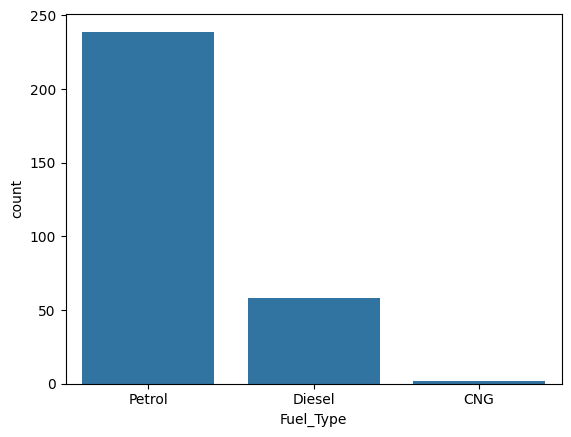

In [21]:
sns.countplot(x='Fuel_Type', data=df)

<Axes: >

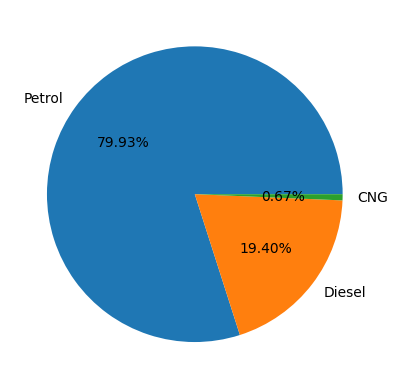

In [31]:
df["Fuel_Type"].value_counts().plot(kind='pie', autopct='%.2f%%')

<Axes: xlabel='Selling_type', ylabel='count'>

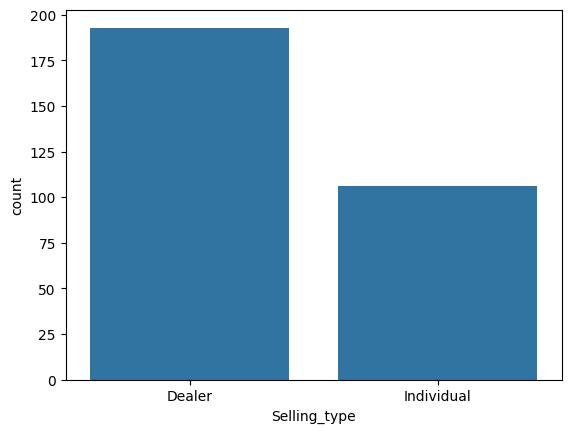

In [23]:
sns.countplot(x='Selling_type', data=df)

<Axes: >

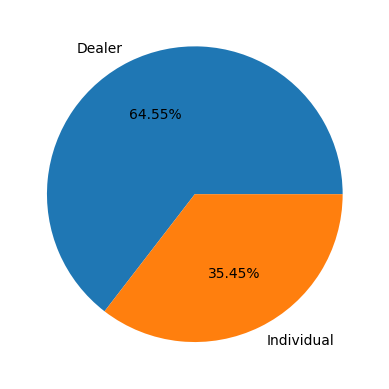

In [30]:
df["Selling_type"].value_counts().plot(kind='pie', autopct='%.2f%%')

<Axes: >

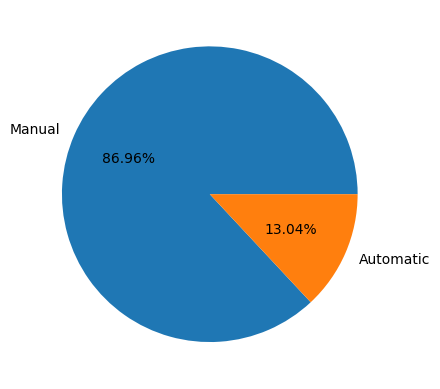

In [29]:
df["Transmission"].value_counts().plot(kind='pie', autopct='%.2f%%')

### Numerical Data Analysis

In [32]:
num = df.select_dtypes(include=np.number)
num.columns

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner'], dtype='str')

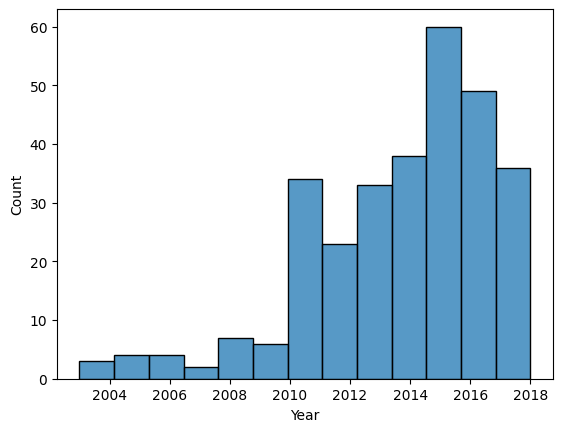

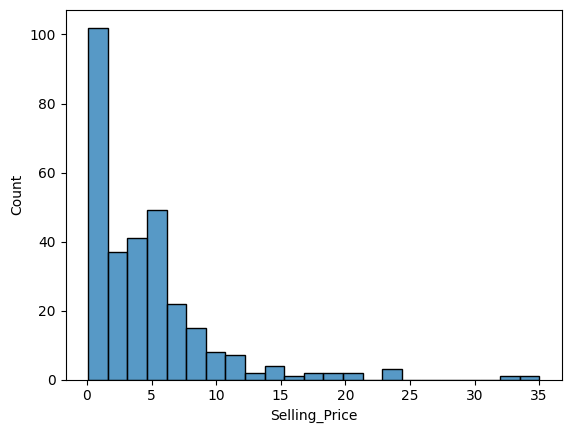

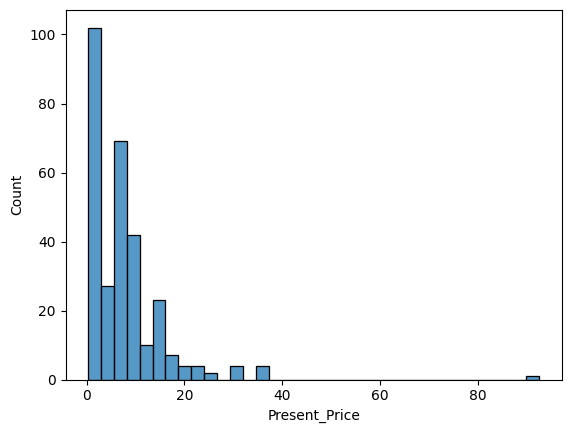

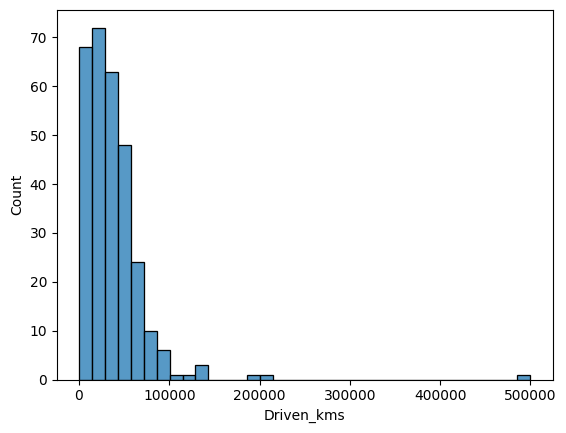

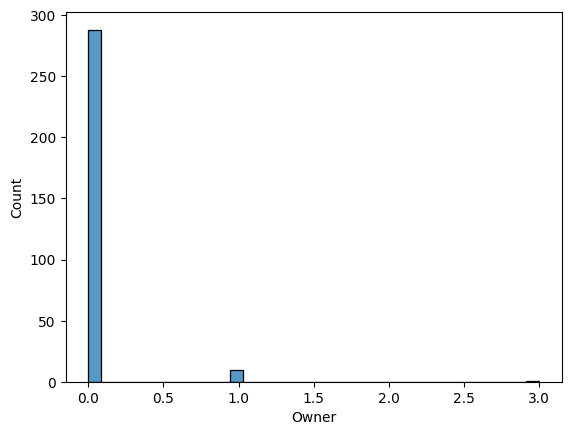

In [37]:
for col in num.columns:
    sns.histplot(x=col, data=num)
    plt.show()

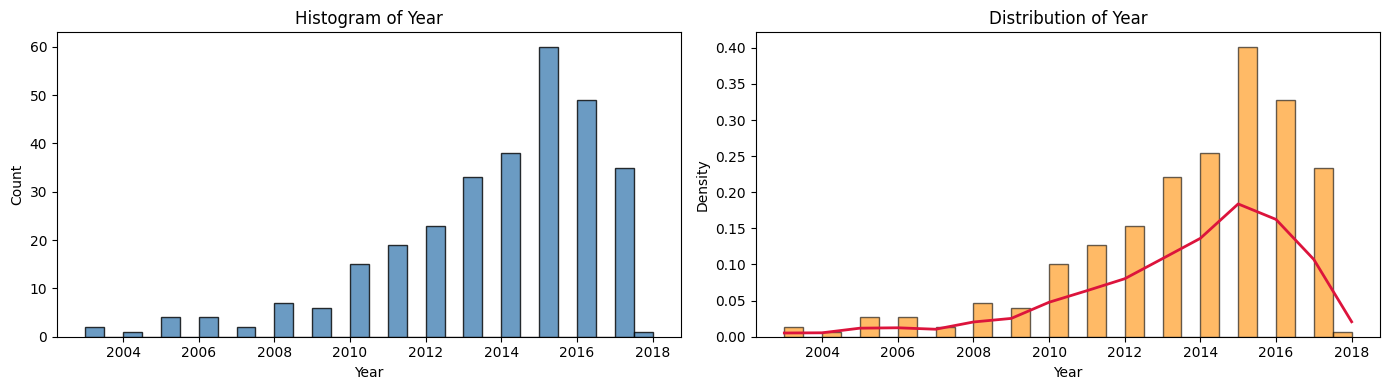

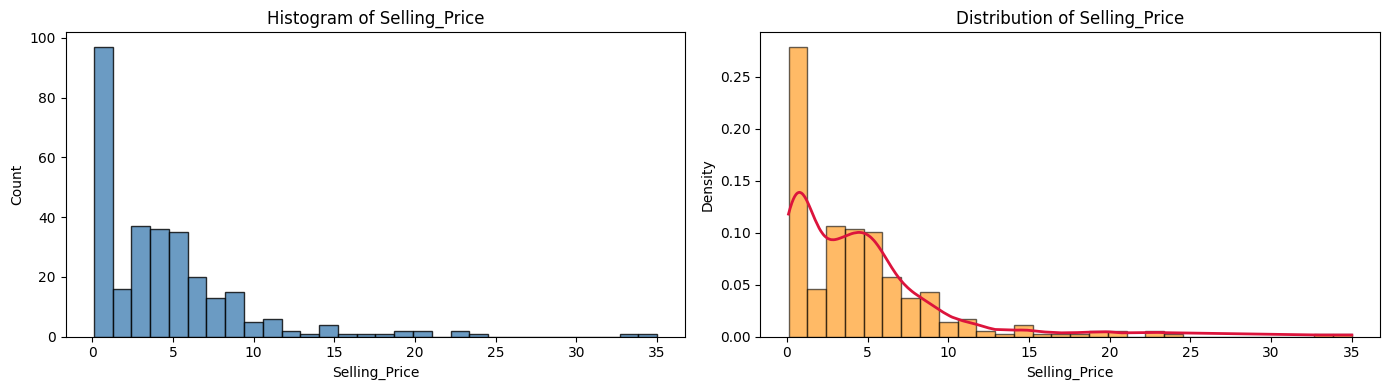

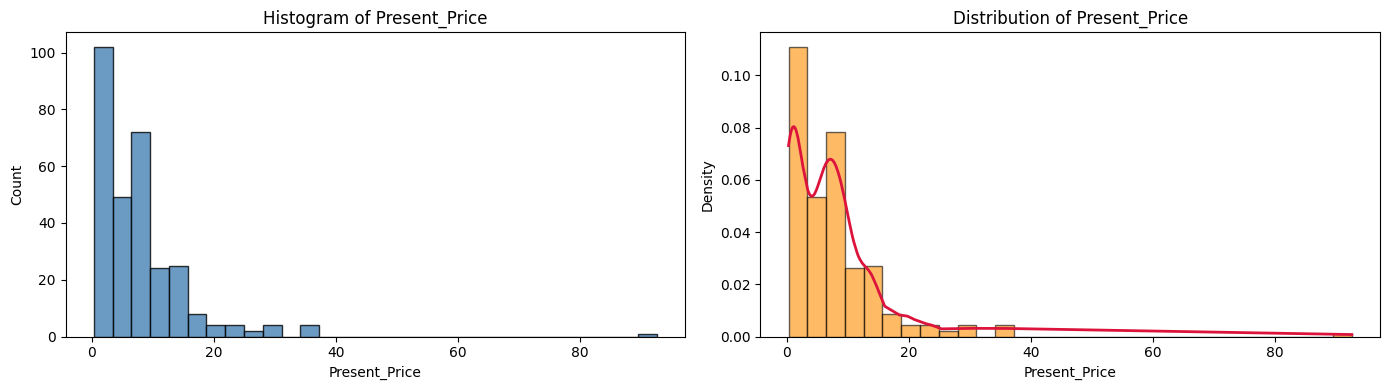

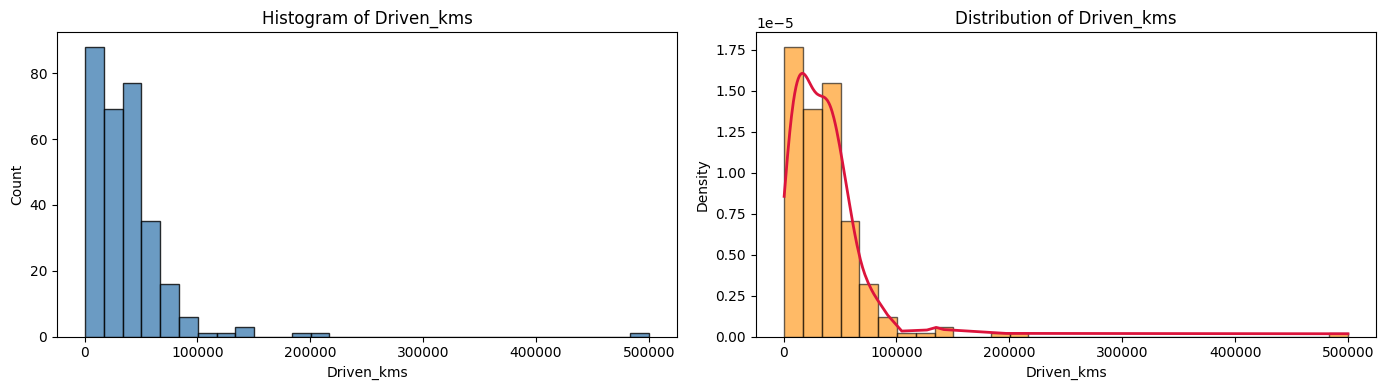

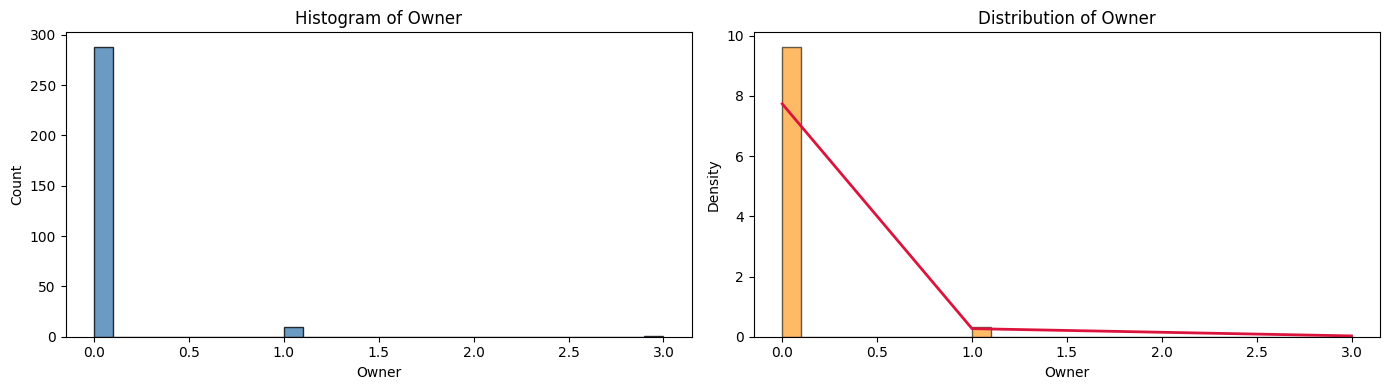

In [39]:
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) == 0:
    print('No numeric columns found.')
else:
    for col in numeric_cols:
        data = df[col].dropna()
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
        axes[0].set_title(f'Histogram of {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Count')

        axes[1].hist(data, bins=30, density=True, color='darkorange', edgecolor='black', alpha=0.6)
        data_sorted = np.sort(data)
        if len(data_sorted) > 1:
            bandwidth = max(data_sorted.std() * 0.2, 1e-6)
            kernel = np.exp(-0.5 * ((data_sorted[:, None] - data_sorted[None, :]) / bandwidth) ** 2)
            density = kernel.sum(axis=1) / (len(data_sorted) * bandwidth * np.sqrt(2 * np.pi))
            axes[1].plot(data_sorted, density, color='crimson', linewidth=2)

        axes[1].set_title(f'Distribution of {col}')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Density')

        plt.tight_layout()
        plt.show()

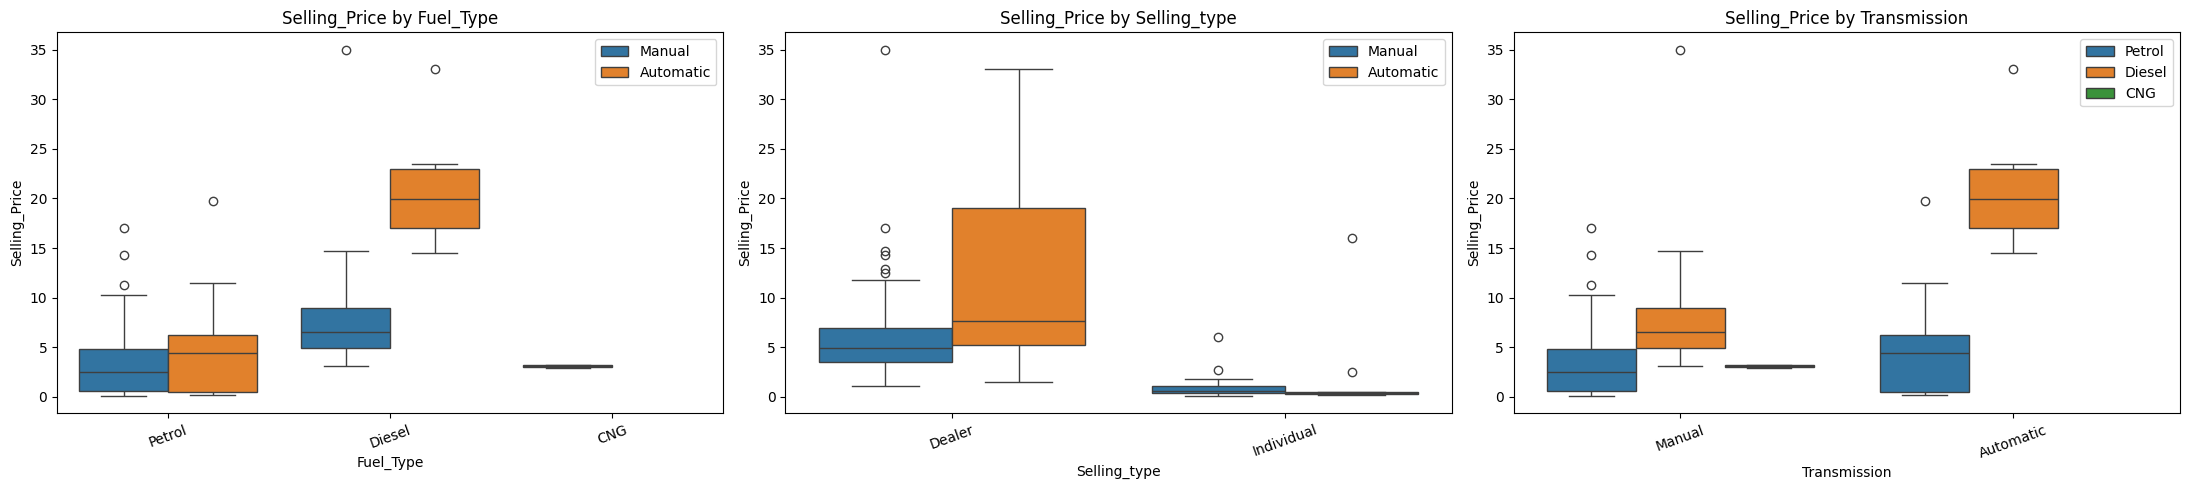

In [40]:
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

if not all(col in df.columns for col in categorical_cols):
    missing_cols = [col for col in categorical_cols if col not in df.columns]
    print(f'Missing columns: {missing_cols}')
else:
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', hue='Transmission', ax=axes[0])
    axes[0].set_title('Selling_Price by Fuel_Type')
    axes[0].tick_params(axis='x', rotation=20)

    sns.boxplot(data=df, x='Selling_type', y='Selling_Price', hue='Transmission', ax=axes[1])
    axes[1].set_title('Selling_Price by Selling_type')
    axes[1].tick_params(axis='x', rotation=20)

    sns.boxplot(data=df, x='Transmission', y='Selling_Price', hue='Fuel_Type', ax=axes[2])
    axes[2].set_title('Selling_Price by Transmission')
    axes[2].tick_params(axis='x', rotation=20)

    for ax in axes:
        ax.legend(title='')

    plt.tight_layout()
    plt.show()

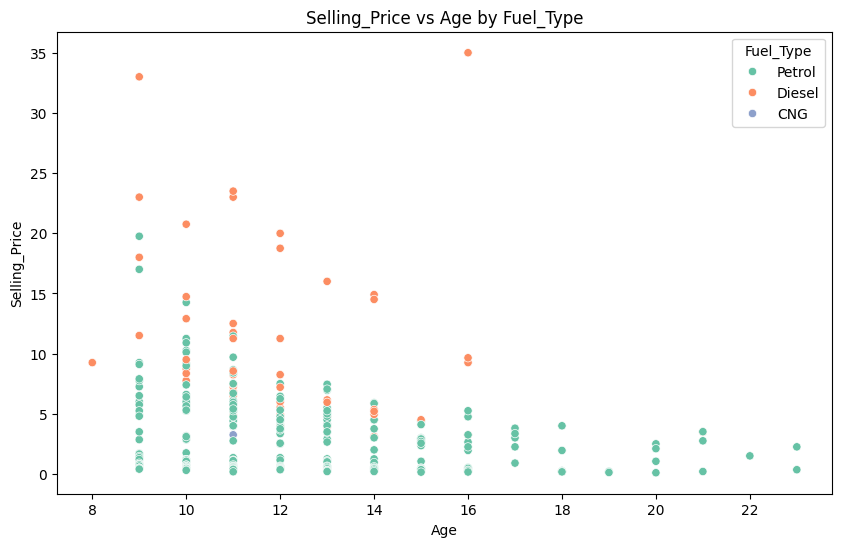

In [43]:
if 'Age' not in df.columns:
    if 'Year' in df.columns:
        df['Age'] = pd.Timestamp.now().year - df['Year']
    else:
        raise KeyError("Neither 'Age' nor 'Year' exists in df")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Selling_Price', hue='Fuel_Type', palette='Set2')
plt.title('Selling_Price vs Age by Fuel_Type')
plt.xlabel('Age')
plt.ylabel('Selling_Price')
plt.show()

In [48]:
df["Mileage_per_year"] = df["Driven_kms"] / df["Age"]

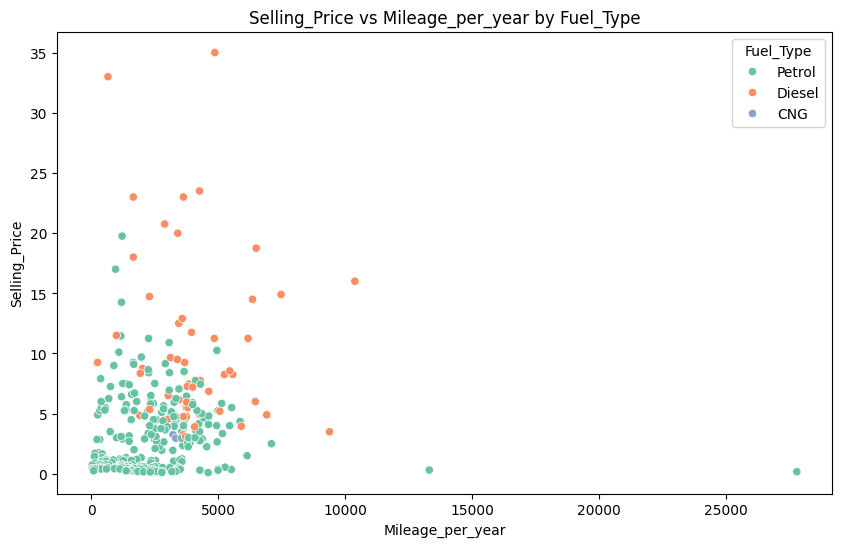

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mileage_per_year', y='Selling_Price', hue='Fuel_Type', palette='Set2')
plt.title('Selling_Price vs Mileage_per_year by Fuel_Type')
plt.xlabel('Mileage_per_year')
plt.ylabel('Selling_Price')
plt.show()

missing: 0 negatives: 0
skew before: 4.971629362024426
skew after : -1.2605544816561847


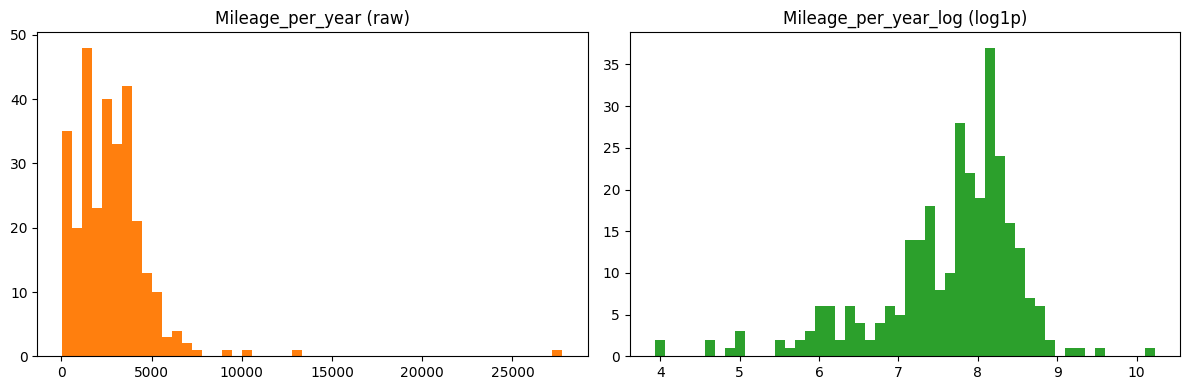

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# safe copy and replace infinities
sp = df["Mileage_per_year"].replace([np.inf, -np.inf], np.nan)

# inspect problematic values
print("missing:", sp.isna().sum(), "negatives:", (sp < 0).sum())
if (sp < 0).any():
    display(df.loc[sp < 0, ["Driven_kms", "Age", "Mileage_per_year"]])

# create log1p feature (clip negatives to 0 if they are erroneous)
sp_safe = sp.clip(lower=0)          # zero or positive only
df["Mileage_per_year_log"] = np.log1p(sp_safe)

# compare skew and quick plots
print("skew before:", df["Mileage_per_year"].skew())
print("skew after :", df["Mileage_per_year_log"].skew())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df["Mileage_per_year"].dropna(), bins=50, color="C1")
ax1.set_title("Mileage_per_year (raw)")
ax2.hist(df["Mileage_per_year_log"].dropna(), bins=50, color="C2")
ax2.set_title("Mileage_per_year_log (log1p)")
plt.tight_layout()
plt.show()

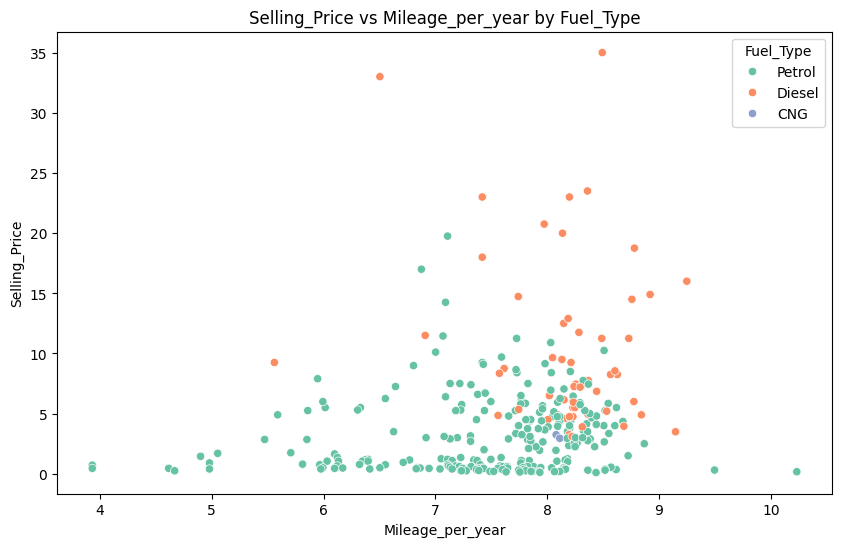

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mileage_per_year_log', y='Selling_Price', hue='Fuel_Type', palette='Set2')
plt.title('Selling_Price vs Mileage_per_year by Fuel_Type')
plt.xlabel('Mileage_per_year')
plt.ylabel('Selling_Price')
plt.show()

### Data Preprocessing & Feature Engineering

In [75]:
df2 = df.copy()
current_year = pd.Timestamp.now().year

df2["Age"] = current_year - df2["Year"]
print(df2[["Year", "Age"]].head())

   Year  Age
0  2014   12
1  2013   13
2  2017    9
3  2011   15
4  2014   12


In [76]:
df2 = df2.drop(["Year","Car_Name", "Mileage_per_year"], axis=1) #will use Age instead of Year

label_enc = {}
for col in df2.select_dtypes(include='object').columns:
    l = LabelEncoder()
    df2[col] = l.fit_transform(df2[col])
    label_enc[col] = l

print(df2.head())

   Selling_Price  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0           3.35           5.59       27000          2             0   
1           4.75           9.54       43000          1             0   
2           7.25           9.85        6900          2             0   
3           2.85           4.15        5200          2             0   
4           4.60           6.87       42450          1             0   

   Transmission  Owner  Age  Mileage_per_year_log  
0             1      0   12              7.719130  
1             1      0   13              8.104308  
2             1      0    9              6.643356  
3             1      0   15              5.851244  
4             1      0   12              8.171458  


C:\Users\hp\AppData\Local\Temp\ipykernel_19620\3528704943.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df2.select_dtypes(include='object').columns:


### Feature Selection & Train-Test Split

In [77]:
X=df2.drop("Selling_Price", axis=1)
y=df2["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 239 samples
Test set size: 60 samples


In [78]:
X_train.head()

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age,Mileage_per_year_log
6,8.12,18796,2,0,1,0,11,7.444089
185,0.58,1900,2,1,0,0,18,4.668666
187,0.51,32000,2,1,1,0,13,7.808948
148,0.94,45000,2,1,1,0,16,7.942185
31,4.89,54200,2,0,1,0,15,8.192663


In [79]:
from sklearn.preprocessing import StandardScaler
standardScaler = StandardScaler()

# fit the scaler to the training data, it will learn parameters
standardScaler.fit(X_train)

# transform train and test data
X_train_scaled = standardScaler.transform(X_train)
X_test_scaled = standardScaler.transform(X_test)

In [80]:
standardScaler.mean_, standardScaler.scale_

(array([7.42140586e+00, 3.44580669e+04, 1.80334728e+00, 3.51464435e-01,
        8.70292887e-01, 2.92887029e-02, 1.23305439e+01, 7.57939161e+00]),
 array([8.81532013e+00, 2.81644105e+04, 4.07858589e-01, 4.77427676e-01,
        3.35980919e-01, 1.68614575e-01, 2.87310937e+00, 9.16152781e-01]))

In [81]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [82]:
X_train_scaled

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age,Mileage_per_year_log
0,0.079248,-0.556094,0.482159,-0.736163,0.386055,-0.173702,-0.463102,-0.147685
1,-0.776081,-1.156000,0.482159,1.358395,-2.590305,-0.173702,1.973282,-3.177118
2,-0.784022,-0.087276,0.482159,1.358395,0.386055,-0.173702,0.233008,0.250566
3,-0.735243,0.374300,0.482159,1.358395,0.386055,-0.173702,1.277172,0.395996
4,-0.287160,0.700953,0.482159,-0.736163,0.386055,-0.173702,0.929117,0.669398
...,...,...,...,...,...,...,...,...
234,-0.756797,0.906887,0.482159,1.358395,0.386055,-0.173702,1.973282,0.581384
235,1.269222,0.764899,0.482159,-0.736163,0.386055,-0.173702,0.233008,0.861228
236,-0.671718,-0.584357,0.482159,1.358395,0.386055,-0.173702,-0.811157,-0.090917
237,0.292513,-0.243501,0.482159,-0.736163,0.386055,-0.173702,-0.463102,0.271442


In [83]:
print(np.round(X_train.describe(), 2))
print(np.round(X_train_scaled.describe(), 2))

       Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  \
count         239.00      239.00     239.00        239.00        239.00   
mean            7.42    34458.07       1.80          0.35          0.87   
std             8.83    28223.52       0.41          0.48          0.34   
min             0.32      500.00       0.00          0.00          0.00   
25%             1.18    14750.00       2.00          0.00          1.00   
50%             5.97    30753.00       2.00          0.00          1.00   
75%             9.40    47500.00       2.00          1.00          1.00   
max            92.60   213000.00       2.00          1.00          1.00   

        Owner     Age  Mileage_per_year_log  
count  239.00  239.00                239.00  
mean     0.03   12.33                  7.58  
std      0.17    2.88                  0.92  
min      0.00    9.00                  3.93  
25%      0.00   10.00                  7.16  
50%      0.00   12.00                  7.82  
75

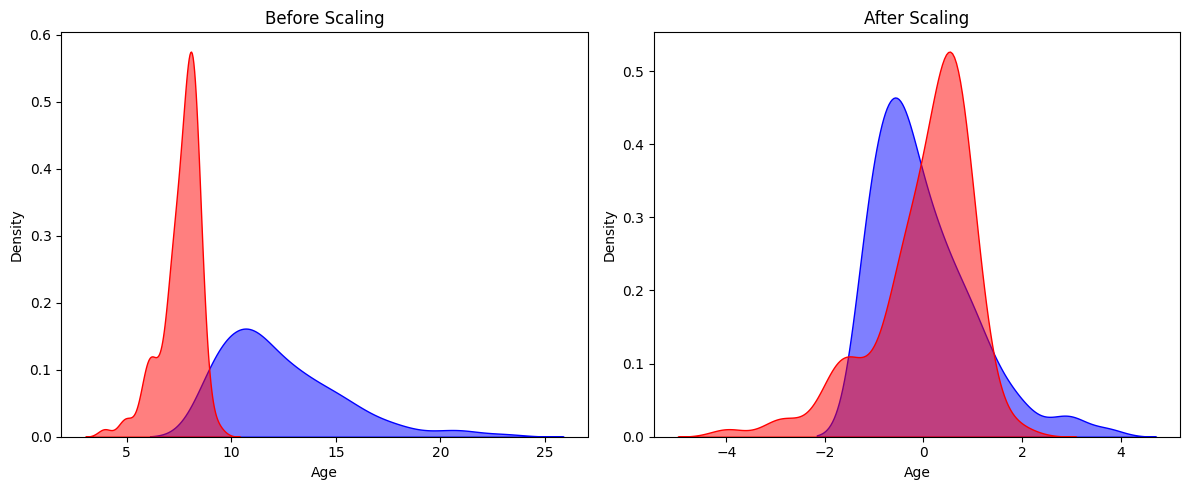

In [85]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before Scaling
sns.kdeplot(X_train["Age"], ax=ax1, fill=True, color="blue", alpha=0.5)
sns.kdeplot(X_train["Mileage_per_year_log"], ax=ax1, fill=True, color="red", alpha=0.5)
ax1.set_title("Before Scaling")
# After Scaling
sns.kdeplot(X_train_scaled["Age"], ax=ax2, fill=True, color="blue", alpha=0.5)
sns.kdeplot(X_train_scaled["Mileage_per_year_log"], ax=ax2, fill=True, color="red", alpha=0.5)
ax2.set_title("After Scaling")
plt.tight_layout()
plt.show()

In [87]:
from sklearn.pipeline import Pipeline

num_trans = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# combine transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', num_trans, X_train.select_dtypes(include=np.number).columns),
    ('cat', cat_trans, X_train.select_dtypes(include='object').columns)
])

# proceessed
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Processed training set shape: {X_train_processed.shape}')
print(f'Processed test set shape: {X_test_processed.shape}')

Processed training set shape: (239, 8)
Processed test set shape: (60, 8)


### Model Training & Evaluation

In [90]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=300, max_features='sqrt', min_samples_split=2, min_samples_leaf=1, random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
}

results = {}

for name, reg in models.items():
    reg.fit(X_train_processed, y_train)
    y_pred = reg.predict(X_test_processed)

    # matrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = np.mean(np.abs(y_test - y_pred))
    
    results[name] = {
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    }

    print(f"{name} Result \nMSE: {mse:.3f}\nMAE: {mae:.3f}\nR2: {r2:.3f}\n")


LinearRegression Result 
MSE: 7.025
MAE: 1.586
R2: 0.727

Ridge Result 
MSE: 7.001
MAE: 1.583
R2: 0.728

Lasso Result 
MSE: 6.888
MAE: 1.572
R2: 0.733

RandomForestRegressor Result 
MSE: 7.491
MAE: 1.265
R2: 0.709

GradientBoostingRegressor Result 
MSE: 7.707
MAE: 1.209
R2: 0.701



In [ ]:
# comparison dataframe
results_df = pd.DataFrame(results).T
print(results_df)

                                MSE       MAE        R2
LinearRegression           7.024543  1.586329  0.727448
Ridge                      7.000669  1.583319  0.728375
Lasso                      6.887912  1.572438  0.732750
RandomForestRegressor      7.490686  1.264939  0.709362
GradientBoostingRegressor  7.707431  1.208645  0.700952


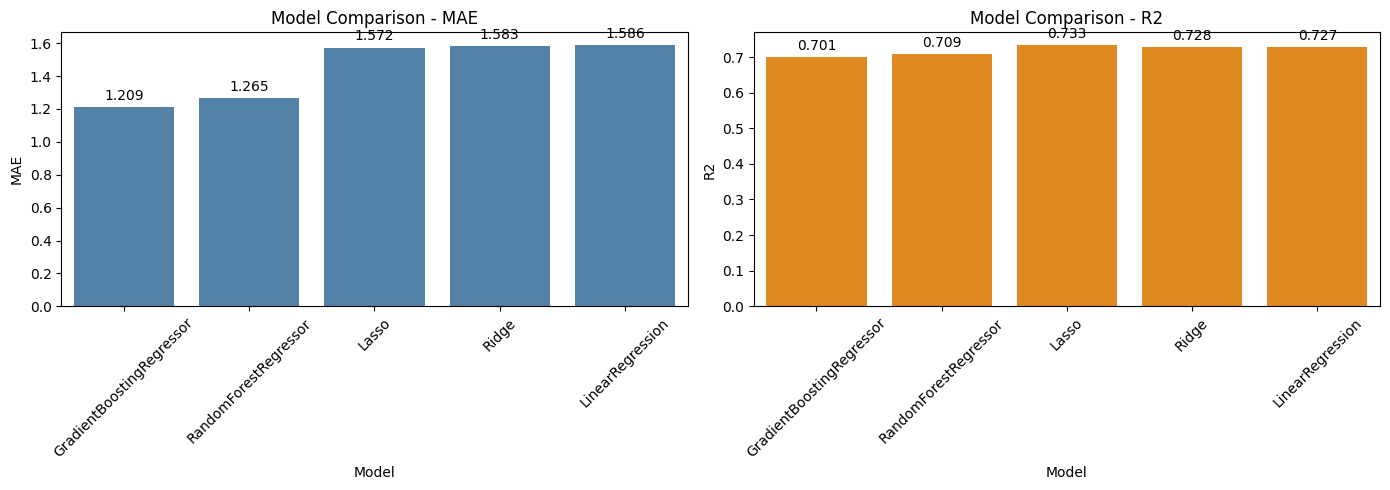

In [93]:
plot_df = results_df.sort_values(by="MAE")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE plot
ax1 = sns.barplot(x=plot_df.index, y=plot_df["MAE"], ax=axes[0], color="steelblue")
axes[0].set_title("Model Comparison - MAE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=45)

for container in ax1.containers:
    ax1.bar_label(container, fmt="%.3f", padding=3)

# R2 plot
ax2 = sns.barplot(x=plot_df.index, y=plot_df["R2"], ax=axes[1], color="darkorange")
axes[1].set_title("Model Comparison - R2")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R2")
axes[1].tick_params(axis='x', rotation=45)

for container in ax2.containers:
    ax2.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

### Best Balanced Model: Lasso Regression
(alpha=0.01)

In [103]:
bestModel = Lasso(alpha=0.01)
bestModel.fit(X_train_processed, y_train)
y_pred = bestModel.predict(X_test_processed)

C:\Users\hp\AppData\Local\Temp\ipykernel_19620\332316354.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', ax=axes[2, 0], palette='viridis')


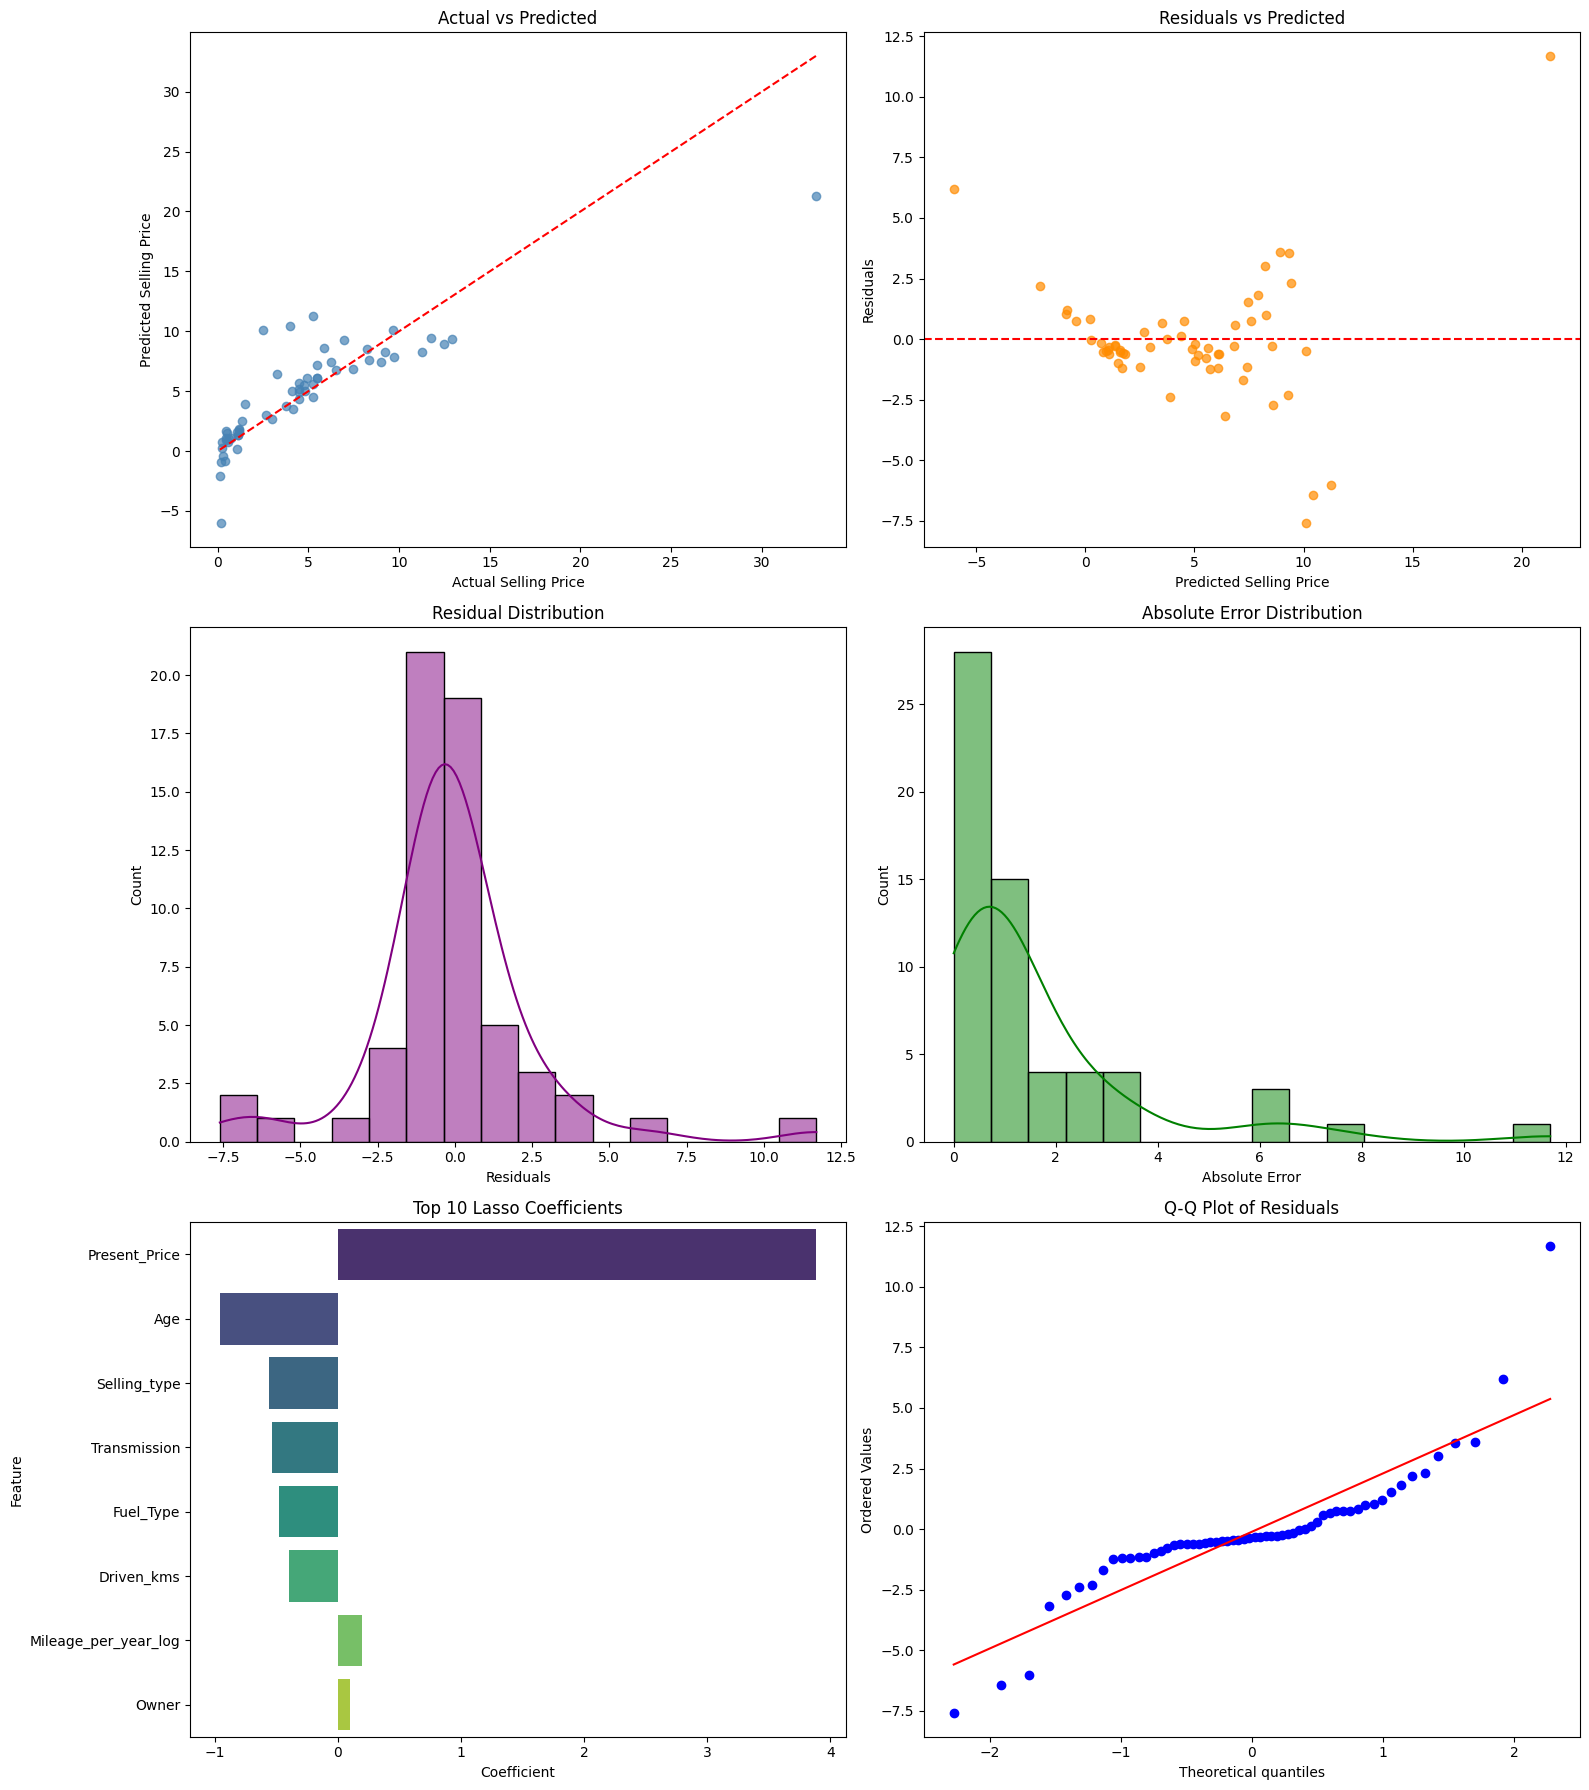

In [104]:
from scipy import stats

# If X_train_processed is a NumPy array and X_train is a DataFrame
feature_names = X_train.columns

residuals = y_test - y_pred
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.7, color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].set_xlabel('Actual Selling Price')
axes[0, 0].set_ylabel('Predicted Selling Price')

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred, residuals, alpha=0.7, color='darkorange')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted Selling Price')
axes[0, 1].set_ylabel('Residuals')

# 3. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Residual Distribution')
axes[1, 0].set_xlabel('Residuals')

# 4. Error histogram
sns.histplot(abs_errors, kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Absolute Error Distribution')
axes[1, 1].set_xlabel('Absolute Error')

# 5. Coefficient importance plot
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': bestModel.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title('Top 10 Lasso Coefficients')
axes[2, 0].set_xlabel('Coefficient')
axes[2, 0].set_ylabel('Feature')

# 6. Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2, 1])
axes[2, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

### Sample Prediction & Visualization

In [107]:
X_train["Fuel_Type"]

6      2
185    2
187    2
148    2
31     2
      ..
190    2
72     2
108    2
272    2
104    2
Name: Fuel_Type, Length: 239, dtype: int64

In [130]:
def predict_price(model, input_data):
    input_df = pd.DataFrame([input_data])

    # convert categorical strings to the same encoded values used in training
    input_df["Fuel_Type"] = label_enc["Fuel_Type"].transform(input_df["Fuel_Type"])
    input_df["Selling_type"] = label_enc["Selling_type"].transform(input_df["Selling_type"])
    input_df["Transmission"] = label_enc["Transmission"].transform(input_df["Transmission"])

    input_processed = preprocessor.transform(input_df)
    predicted_price = model.predict(input_processed)
    return predicted_price[0]

sample_input = {
    'Age': 6,
    'Present_Price': 15.0,
    'Driven_kms': 50000,
    'Mileage_per_year_log': np.log1p(11000),
    'Fuel_Type': 'Diesel',
    'Selling_type': 'Individual',
    'Owner': 1,
    'Transmission': 'Manual'
}

predicted_price = predict_price(bestModel, sample_input)
print(f"Predicted Selling Price: {predicted_price:.2f} lakhs")

Predicted Selling Price: 10.75 lakhs
